In [131]:
# load the K562 lentiMPRA single-seq ISM (saturation-mutagenesis) maps for one seed
# gradient-corrected (mean-centered across channels) -- analog of hypothetical DeepLIFT
import sys, os, numpy as np, pandas as pd
import h5py
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
sys.path.append("/grid/koo/home/pmantill/projects/VBI/init_impliment/scripts")
from fast_logo import fast_logo

seam_dir = "/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq"
peak = "peak84030"               # top K562 lentiMPRA seed (seam_seeds.csv)

lib    = "100k"                           # <-- switch library size here: "100k" or "200k"
suffix = {"100k": "", "200k": "_200k"}[lib]

with h5py.File(f"{seam_dir}/ism{suffix}/{peak}.h5") as f:
    attributions = f["ism_centered"][:]   # (N, 200, 4) ISM, mean-centered across channels
    predictions  = f["predictions"][:]    # (N,) self-prediction of each mutant

with h5py.File(f"{seam_dir}/mutagenesis_lib{suffix}/{peak}.h5") as f:
    wt_sequence = f["wt_sequence"][:]     # (230, 4) with 15bp adapters

wt_onehot = wt_sequence[15:215]           # variable region matches attributions axis
wt_attr   = attributions[0]               # WT attribution map (index 0)

# flatten: each Lx4 attribution map -> one observation in R^D, D=4L
L = attributions.shape[1]
X = attributions.reshape(attributions.shape[0], -1).astype(np.float32)   # (N, 4L)
N, D = X.shape
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_t = torch.from_numpy(X).to(device)
var_data = X.var(0) + 1e-8                 # (D,) global per-dim variance (bg cov seed)
print(f"[{lib}] N={N:,}  D={D} (=4*{L})  device={device}")

[100k] N=100,000  D=800 (=4*200)  device=cuda


In [132]:
# ----- hyperparameters (mixture side matches free_bay_GMM.ipynb: K=200, alpha0=1e-3) -----
# SKIP-CONNECTION VARIANT: encoder & decoder each = pre-projection -> residual block -> head.
J        = 16        # latent (foreground code) dimension
K        = 200       # initial number of GMM components (sparse Dirichlet prunes unused)
alpha0   = 1      # Dirichlet concentration (alpha0 < 1 -> sparse -> learns K)
hidden   = 256       # MLP width
seed     = 13
torch.manual_seed(seed); rng = np.random.default_rng(seed)



class VAE_GMM(nn.Module):
    """VAE over the foreground f=decoder(z); shared bg Gaussian N(mu_b,sigma_b^2) added before the
    reconstruction; GMM(K) prior on z. Mixture weights: Dirichlet(alpha0) with a Dirichlet posterior.
    Component (mean, precision): diagonal Normal-Gamma prior with a variational NG posterior
    q(mu_kj,tau_kj)=N(mu|m,(kappa*tau)^-1) Gamma(tau|a,b), both updated by closed-form M-steps.
    SKIP CONNECTIONS: encoder and decoder each carry a residual block h = h + ReLU(Linear(h))
    across the matched-width hidden layer (pre-projection D->hidden / J->hidden, head off the block)."""
    def __init__(self, D, J, K, alpha0, hidden, var_data,
                 m0=0.0, kappa0=1.0, a0=1.0, b0=1.0):        # weakly-informative NG prior (tunable)
        super().__init__()
        self.D, self.J, self.K, self.alpha0 = D, J, K, alpha0
        # encoder q(z|x)=N(mu_z, diag sigma_z^2): D -> hidden, residual block, then (mu,lv) heads
        self.enc_in  = nn.Linear(D, hidden)
        self.enc_res = nn.Linear(hidden, hidden)
        self.enc_mu  = nn.Linear(hidden, J)
        self.enc_lv  = nn.Linear(hidden, J)
        # decoder p(f|z) -> foreground in R^D: J -> hidden, residual block, then -> D
        self.dec_in  = nn.Linear(J, hidden)
        self.dec_res = nn.Linear(hidden, hidden)
        self.dec_out = nn.Linear(hidden, D)
        # shared background Gaussian: free mean starts at ZERO (free-bg variant); cov is ISOTROPIC
        self.mu_b     = nn.Parameter(torch.zeros(D))
        self.log_var_b = nn.Parameter(torch.tensor(float(np.log(var_data.mean()))))   # scalar
        # ---- GMM components: Normal-Gamma prior + variational NG posterior on (mu_c, tau_c) ----
        # These are BUFFERS (not Parameters): like alpha, they are set by closed-form M-steps, not Adam.
        # per-dim diagonal: m,b are (K,J); kappa,a depend only on N_k so they are (K,).
        self.m0, self.kappa0, self.a0, self.b0 = float(m0), float(kappa0), float(a0), float(b0)
        self.register_buffer("m_",     torch.zeros(K, J))
        self.register_buffer("kappa_", torch.full((K,), float(kappa0)))
        self.register_buffer("a_",     torch.full((K,), float(a0)))
        self.register_buffer("b_",     torch.full((K, J), float(b0)))
        # q(pi)=Dir(alpha). A BUFFER, not a Parameter: alpha is a natural parameter of the Dirichlet
        # and is set by the closed-form M-step, so it needs no positivity reparameterization and must
        # not be seen by the optimizer. (The softplus(alpha_raw) form only made sense for SGD on alpha.)
        self.register_buffer("alpha_", torch.full((K,), alpha0 + 1.0))

    @property
    def alpha(self):
        return self.alpha_

    def ng_expect(self):
        """expectations under q(mu,tau)=NG: E[tau]=a/b, E[log tau]=psi(a)-log b  -> both (K,J)."""
        E_tau    = self.a_[:, None] / self.b_
        E_logtau = torch.digamma(self.a_)[:, None] - torch.log(self.b_)
        return E_tau, E_logtau

    def elogN(self, mu_z, s2):
        """E_{q(mu,tau)}[log N(z|mu_k,tau_k^-1)] averaged over q(z|x)=N(mu_z,s2) -> (B,K)."""
        E_tau, E_logtau = self.ng_expect()                              # (K,J)
        diff2 = (mu_z[:, None, :] - self.m_[None])**2 + s2[:, None, :]  # (B,K,J): E_z[(z-m)^2]
        return 0.5 * ((E_logtau[None] - np.log(2*np.pi))
                      - E_tau[None] * diff2
                      - (1.0 / self.kappa_)[None, :, None]).sum(-1)     # (B,K)

    def kl_ng(self):
        """sum_{k,j} KL[ NG_q(m,kappa,a,b) || NG_prior(m0,kappa0,a0,b0) ]  (scalar)."""
        aE, b, k, m = self.a_[:, None], self.b_, self.kappa_, self.m_
        a0, b0, k0, m0 = self.a0, self.b0, self.kappa0, self.m0
        kl_gamma = (a0 * torch.log(b / b0) + (aE - a0) * torch.digamma(aE)
                    - torch.lgamma(aE) + torch.lgamma(torch.tensor(a0)) + aE * (b0 - b) / b)
        kl_gauss = (0.5 * torch.log(k / k0)[:, None] + 0.5 * (k0 / k)[:, None] - 0.5
                    + 0.5 * k0 * (aE / b) * (m - m0)**2)
        return (kl_gamma + kl_gauss).sum()

    @torch.no_grad()
    def m_step_alpha(self, Nk):
        """Exact ELBO maximizer for the Dirichlet posterior: alpha_k = alpha0 + N_k."""
        self.alpha_.copy_(self.alpha0 + torch.as_tensor(Nk, dtype=torch.float32, device=self.alpha_.device))

    @torch.no_grad()
    def m_step_ng(self, Nk, S1, S2):
        """Closed-form CAVI update of the component NG posterior (Bishop 10.60-10.63, diagonal).
        Nk (K,)  S1=sum_n gamma*mu_z (K,J)  S2=sum_n gamma*(mu_z^2+s2) (K,J)."""
        Nk_safe = Nk.clamp_min(1e-8)
        self.kappa_.copy_(self.kappa0 + Nk)
        self.a_.copy_(self.a0 + 0.5 * Nk)
        self.m_.copy_((self.kappa0 * self.m0 + S1) / self.kappa_[:, None])
        xbar = S1 / Nk_safe[:, None]
        NkS  = S2 - S1**2 / Nk_safe[:, None]                         # = N_k * weighted var (robust to N_k=0)
        coef = (self.kappa0 * Nk / (self.kappa0 + Nk))[:, None]
        b_new = self.b0 + 0.5 * (NkS + coef * (xbar - self.m0)**2)
        self.b_.copy_(b_new.clamp_min(1e-8))

    def encode(self, x):
        h = F.relu(self.enc_in(x))
        h = h + F.relu(self.enc_res(h))              # residual (skip) block
        return self.enc_mu(h), self.enc_lv(h)

    def decode(self, z):
        h = F.relu(self.dec_in(z))
        h = h + F.relu(self.dec_res(h))              # residual (skip) block
        return self.dec_out(h)

    def recon_loss(self, x):
        # STACKED-AUTOENCODER warmup: reconstruction (MSE) ONLY -- deterministic z=mu_z, no reparam, no KL
        mu_z, _ = self.encode(x)
        recon = self.decode(mu_z) + self.mu_b
        return ((x - recon)**2).sum(-1).mean()

    def forward(self, x, n_total):
        mu_z, lv_z = self.encode(x)                              # (B,J)
        s2 = torch.exp(lv_z)
        z = mu_z + torch.randn_like(mu_z) * torch.sqrt(s2)
        recon = self.decode(z) + self.mu_b                       # f + b  (mean of x)

        # reconstruction: log p(x-b|z) = log N(x; recon, sigma_b^2 I)
        log_p_x = -0.5 * (np.log(2*np.pi) + self.log_var_b
                          + (x - recon)**2 * torch.exp(-self.log_var_b)).sum(-1)   # (B,)

        # E_q(mu,tau)[log N(z|mu_k,tau_k^-1)] over q(z|x) -> (B,K); responsibilities via softmax
        ElogN   = self.elogN(mu_z, s2)                               # (B,K)
        Elog_pi = torch.digamma(self.alpha) - torch.digamma(self.alpha.sum())   # (K,) E_q[log pi]
        log_un  = Elog_pi[None] + ElogN                             # (B,K)
        log_gamma = log_un - torch.logsumexp(log_un, 1, keepdim=True)
        gamma = log_gamma.exp().detach()                             # responsibilities (E-step)

        Hqz      = 0.5 * (1.0 + np.log(2*np.pi) + lv_z).sum(-1)      # entropy of q(z|x)
        klz_term = (gamma * ElogN).sum(-1) + Hqz                    # E_q[log p(z|c)] + H[q(z)]
        cat_term = (gamma * (Elog_pi[None] - log_gamma)).sum(-1)    #  sum_k gamma_k log(pi_k/gamma_k)
        elbo_n   = log_p_x + klz_term + cat_term                    # (B,)

        # Dirichlet KL[ q(pi) || Dir(alpha0) ]  (global; scaled per-sample by 1/N)
        alpha = self.alpha
        kl_pi = (torch.lgamma(alpha.sum()) - torch.lgamma(alpha).sum()
                 - torch.lgamma(torch.tensor(self.K * alpha0, device=x.device))
                 + self.K * torch.lgamma(torch.tensor(alpha0, device=x.device))
                 + ((alpha - alpha0) * Elog_pi).sum())

        loss = -elbo_n.mean() + (kl_pi + self.kl_ng()) / n_total
        return loss, elbo_n.mean().detach(), gamma, mu_z.detach(), s2.detach()

model = VAE_GMM(D, J, K, alpha0, hidden, var_data).to(device)
print(model)

VAE_GMM(
  (enc_in): Linear(in_features=800, out_features=256, bias=True)
  (enc_res): Linear(in_features=256, out_features=256, bias=True)
  (enc_mu): Linear(in_features=256, out_features=16, bias=True)
  (enc_lv): Linear(in_features=256, out_features=16, bias=True)
  (dec_in): Linear(in_features=16, out_features=256, bias=True)
  (dec_res): Linear(in_features=256, out_features=256, bias=True)
  (dec_out): Linear(in_features=256, out_features=800, bias=True)
)


warmup epoch   0  recon MSE/n 3.62326
warmup epoch   5  recon MSE/n 1.62878
warmup epoch  10  recon MSE/n 1.51173
warmup epoch  15  recon MSE/n 1.46085
warmup epoch  20  recon MSE/n 1.43551
warmup epoch  25  recon MSE/n 1.41839
warmup epoch  29  recon MSE/n 1.40666


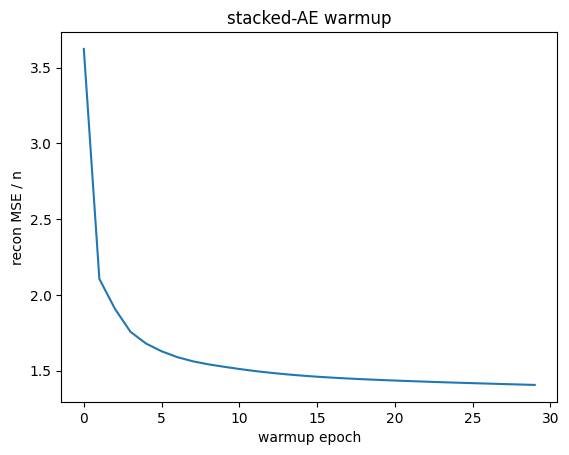

In [133]:
# ----- WARMUP: stacked autoencoder -- train encoder+decoder (+bg mean) on RECONSTRUCTION (MSE) ONLY -----
# deterministic z=mu_z, no reparam, no KL term. Just makes the latent meaningful before clustering.
warmup_epochs, warmup_batch, warmup_lr = 30, 256, 1e-4

warm_params = list(model.enc_in.parameters()) + list(model.enc_res.parameters()) \
            + list(model.enc_mu.parameters()) + list(model.dec_in.parameters()) \
            + list(model.dec_res.parameters()) + list(model.dec_out.parameters()) + [model.mu_b]
opt_w = torch.optim.Adam(warm_params, lr=warmup_lr)

model.train()
warm_losses = []
for ep in range(warmup_epochs):
    perm = torch.randperm(N, device=device)
    tot = 0.0
    for i in range(0, N, warmup_batch):
        xb = X_t[perm[i:i+warmup_batch]]
        opt_w.zero_grad()
        l = model.recon_loss(xb)
        l.backward(); opt_w.step()
        tot += l.item() * xb.shape[0]
    warm_losses.append(tot / N)
    if ep % 5 == 0 or ep == warmup_epochs - 1:
        print(f"warmup epoch {ep:3d}  recon MSE/n {warm_losses[-1]:.5f}")

plt.plot(warm_losses); plt.xlabel("warmup epoch"); plt.ylabel("recon MSE / n"); plt.title("stacked-AE warmup"); plt.show()

In [134]:
# ----- init the component NG posterior: means at K random DATA latents, width = per-dim latent scale -----
#   m_     <- K randomly drawn data-point latent codes (every component starts ON data, following its density)
#   kappa_ <- kappa0, a_ <- a0
#   b_     <- a0 * Var_j[Z] per latent dim  ->  E[tau_j]=a0/b_j=1/var_j  ->  sigma_j = latent std_j
#            (init each component at the APPROPRIATE per-dim scale, not the prior's unit width)
# The closed-form M-step then tightens each component from the responsibility-weighted z statistics.
model.eval()
with torch.no_grad():
    Z = torch.cat([model.encode(X_t[i:i+4096])[0] for i in range(0, N, 4096)]).cpu().numpy()  # (N,J)

Zvar = Z.var(0) + 1e-8                                        # (J,) per-dim latent variance (component scale)
idx0 = rng.choice(N, K, replace=False)                        # K distinct data-point latent codes
with torch.no_grad():
    model.m_.copy_(torch.from_numpy(Z[idx0]).to(device))     # means = random data latents (as before)
    model.kappa_.fill_(model.kappa0)
    model.a_.fill_(model.a0)
    model.b_.copy_(torch.from_numpy((model.a0 * Zvar).astype(np.float32)).to(device))   # broadcasts (J,)->(K,J)

spread = Z.std(0).mean()
E_tau  = (model.a_[:, None] / model.b_).cpu().numpy()         # (K,J) posterior mean precision
sig    = float(np.mean(1.0 / np.sqrt(E_tau)))                 # mean posterior component sigma
sep    = model.m_.std().item()
print(f"m_=K random data latents, b_=per-dim var | latent spread {spread:.3f} | m_ std={sep:.3f} | "
      f"sigma={sig:.3f} -> sigma/spread {sig/spread:.2f} | separation/width {sep/sig:.3f}")

m_=K random data latents, b_=per-dim var | latent spread 0.206 | m_ std=0.349 | sigma=0.206 -> sigma/spread 1.00 | separation/width 1.697


saved warmup-only snapshot -> /grid/koo/home/pmantill/projects/VBI/VAE_gmm/seperate_benchmark/results/peak84030.100k.J16.K200.h256.a1.warm30.mstep.ng.skip.rfdmu.seed13.warmup_only.pt
epoch   0  ELBO/n  545.496  surviving(argmax) 200  alpha [4.454, 191.512, 6132]
epoch  10  ELBO/n 1218.486  surviving(argmax)  52  alpha [1.000, 1.000, 12308]
epoch  20  ELBO/n 1303.190  surviving(argmax)  51  alpha [1.000, 1.000, 9406]
epoch  30  ELBO/n 1358.547  surviving(argmax)  51  alpha [1.000, 1.000, 7960]
epoch  40  ELBO/n 1380.994  surviving(argmax)  51  alpha [1.000, 1.000, 7180]
epoch  50  ELBO/n 1385.222  surviving(argmax)  51  alpha [1.000, 1.000, 6886]
epoch  60  ELBO/n 1387.834  surviving(argmax)  51  alpha [1.000, 1.000, 6817]
epoch  70  ELBO/n 1389.938  surviving(argmax)  51  alpha [1.000, 1.000, 6756]
epoch  80  ELBO/n 1391.906  surviving(argmax)  51  alpha [1.000, 1.000, 6669]
epoch  90  ELBO/n 1393.603  surviving(argmax)  51  alpha [1.000, 1.000, 6592]
epoch  99  ELBO/n 1395.094  surviv

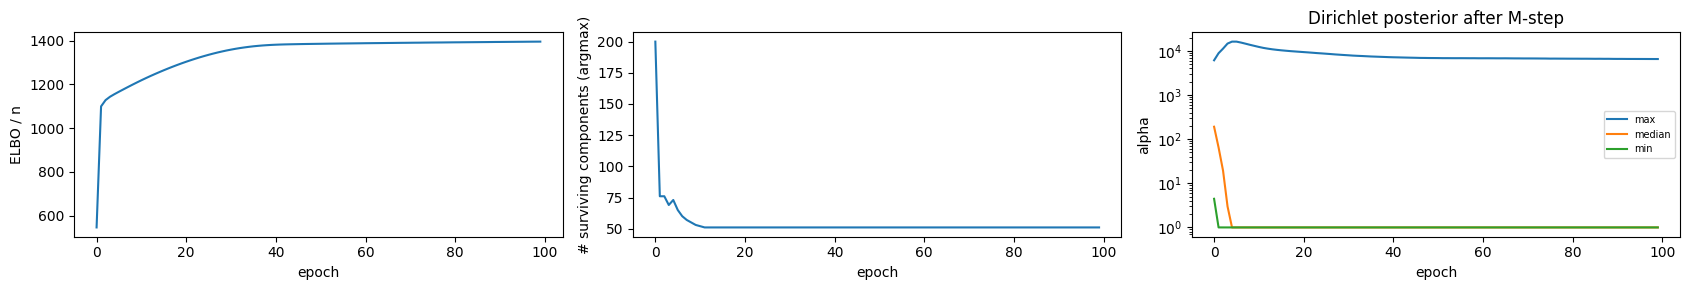

In [135]:
# ----- train full ELBO (Adam for encoder/decoder/bg) + closed-form M-steps each epoch -----
#   - alpha (Dirichlet) and the component NG posterior (m,kappa,a,b) are buffers -> excluded from Adam
#   - responsibilities + z suff-stats are accumulated over the epoch:
#       N_k = sum_n gamma_nk,  S1 = sum_n gamma*mu_z,  S2 = sum_n gamma*(mu_z^2+s2)
#   - at epoch end: alpha_k <- alpha0 + N_k  AND  NG posterior <- CAVI update (exact ELBO maximizers)
#   - init: means at K random latent codes, NG posterior=prior  -> '.rfdmu' in the tag; prior '.ng'
out_dir = "/grid/koo/home/pmantill/projects/VBI/VAE_gmm/seperate_benchmark/results"
os.makedirs(out_dir, exist_ok=True)
hp_tag   = f"{peak}.{lib}.J{J}.K{K}.h{hidden}.a{alpha0:g}.warm{warmup_epochs}.mstep.ng.skip.rfdmu.seed{seed}"
ckpt_path = f"{out_dir}/{hp_tag}.pt"

epochs, batch, lr = 100, 256, 1e-4

if os.path.exists(ckpt_path):
    ck = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ck["state_dict"]); elbos = ck["elbos"]; n_alive_hist = ck["n_alive_hist"]
    alpha_hist = ck["alpha_hist"]
    print(f"loaded cached fit: {ckpt_path}  ({len(elbos)} epochs, final ELBO {elbos[-1]:.3f})")
else:
    # snapshot the post-warmup / pre-VB state (components at cell-3 random-code + NG-prior init) so the
    # benchmark can isolate what the VB M-steps add on top of the stacked-AE warmup.
    warm_ckpt = f"{out_dir}/{hp_tag}.warmup_only.pt"
    torch.save({"state_dict": model.state_dict(),
                "hp": dict(peak=peak, lib=lib, J=J, K=K, hidden=hidden, alpha0=alpha0,
                           warmup_epochs=warmup_epochs, seed=seed, prior="normal_gamma",
                           stage="warmup_only", m0=model.m0, kappa0=model.kappa0,
                           a0=model.a0, b0=model.b0)}, warm_ckpt)
    print(f"saved warmup-only snapshot -> {warm_ckpt}")

    opt = torch.optim.Adam(model.parameters(), lr=lr)     # buffers (alpha, NG posterior) not in parameters()
    elbos, n_alive_hist, alpha_hist = [], [], []
    for ep in range(epochs):
        perm = torch.randperm(N, device=device)
        ep_elbo = 0.0
        Nk = torch.zeros(K, device=device)
        S1 = torch.zeros(K, J, device=device)
        S2 = torch.zeros(K, J, device=device)
        won = torch.zeros(K, dtype=torch.bool, device=device)   # component won >=1 argmax this epoch
        model.train()
        for i in range(0, N, batch):
            xb = X_t[perm[i:i+batch]]
            opt.zero_grad()
            loss, elbo, gamma, mu_z, s2 = model(xb, N)
            loss.backward(); opt.step()
            ep_elbo += float(elbo) * xb.shape[0]
            Nk += gamma.sum(0)                       # gamma, mu_z, s2 already detached in forward
            S1 += gamma.t() @ mu_z                   # (K,J)
            S2 += gamma.t() @ (mu_z**2 + s2)         # (K,J)
            won[gamma.argmax(1)] = True              # hard-assignment survivors (cutoff-free)
        model.m_step_alpha(Nk)                       # <-- exact M-step on the Dirichlet posterior
        model.m_step_ng(Nk, S1, S2)                  # <-- exact CAVI M-step on the component NG posterior
        elbos.append(ep_elbo / N)
        n_alive_hist.append(int(won.sum()))          # real surviving = components winning >=1 argmax
        with torch.no_grad():
            a = model.alpha.cpu().numpy()
        alpha_hist.append([float(a.min()), float(np.median(a)), float(a.max())])
        if ep % 10 == 0 or ep == epochs - 1:
            print(f"epoch {ep:3d}  ELBO/n {elbos[-1]:8.3f}  surviving(argmax) {n_alive_hist[-1]:3d}"
                  f"  alpha [{a.min():.3f}, {np.median(a):.3f}, {a.max():.0f}]")
    torch.save({"state_dict": model.state_dict(), "elbos": elbos, "n_alive_hist": n_alive_hist,
                "alpha_hist": alpha_hist,
                "hp": dict(peak=peak, lib=lib, J=J, K=K, hidden=hidden, alpha0=alpha0,
                           warmup_epochs=warmup_epochs, seed=seed, mstep=True,
                           prior="normal_gamma", m0=model.m0, kappa0=model.kappa0,
                           a0=model.a0, b0=model.b0, init="random_codes_ng_prior")}, ckpt_path)
    print(f"saved -> {ckpt_path}")

ah = np.array(alpha_hist)
fig, ax = plt.subplots(1, 3, figsize=(17, 3))
ax[0].plot(elbos);        ax[0].set_xlabel("epoch"); ax[0].set_ylabel("ELBO / n")
ax[1].plot(n_alive_hist); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("# surviving components (argmax)")
ax[2].semilogy(ah[:, 2], label="max"); ax[2].semilogy(ah[:, 1], label="median"); ax[2].semilogy(ah[:, 0], label="min")
ax[2].set_xlabel("epoch"); ax[2].set_ylabel("alpha"); ax[2].legend(fontsize=7)
ax[2].set_title("Dirichlet posterior after M-step")
plt.tight_layout(); plt.show()

SEAM.kmeans100.100k  surviving clusters=100/100  functional coherence (eta^2)=0.942
RANDOM.k100  surviving clusters=100/100  functional coherence (eta^2)=0.001
peak84030.100k.J16.K200.h256.a0.001.warm50.mstep.ng.skip.rfdmu.seed13  surviving clusters= 11/200  functional coherence (eta^2)=0.861
peak84030.100k.J16.K200.h256.a0.001.warm50.mstep.ng.skip.rfdmu.seed13.warmup_only  surviving clusters=200/200  functional coherence (eta^2)=0.884
peak84030.100k.J16.K200.h256.a0.1.warm50.mstep.ng.skip.rfdmu.seed13  surviving clusters= 11/200  functional coherence (eta^2)=0.860
peak84030.100k.J16.K200.h256.a0.1.warm50.mstep.ng.skip.rfdmu.seed13.warmup_only  surviving clusters=200/200  functional coherence (eta^2)=0.884
peak84030.100k.J16.K200.h256.a1.warm30.mstep.ng.skip.rfdmu.seed13  surviving clusters= 51/200  functional coherence (eta^2)=0.929
peak84030.100k.J16.K200.h256.a1.warm30.mstep.ng.skip.rfdmu.seed13.warmup_only  surviving clusters=200/200  functional coherence (eta^2)=0.923
peak84030.10

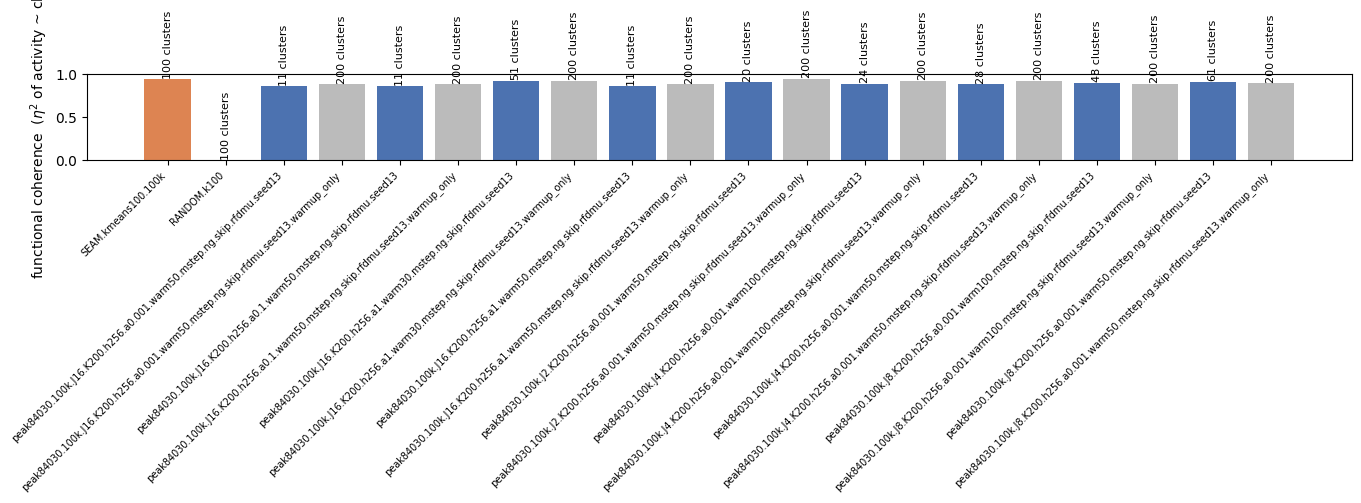

In [136]:
# ----- functional coherence of each model (skip-connection VAE-GMM) -----
# eta^2 = fraction of variance in the activity self-prediction explained by cluster label
# (1 = each cluster functionally homogeneous). Surviving clusters = argmax winners (no cutoff).
# Because the skip encoder is not a plain Sequential, models are rebuilt via the class and loaded;
# only this notebook's *skip* checkpoints are globbed (won't clash with the non-skip notebook's).
import glob

def responsibilities(m):
    """Soft E-step (z=mu_z) under the NG posterior, then keep only SURVIVING components (soft Nk>=1)
    so hard argmax assigns among real clusters, never onto a degenerate 1-point component -- the
    standard VB-GMM way. Returns (N,K) with dead columns zeroed."""
    m.eval()
    Elog_pi = torch.digamma(m.alpha) - torch.digamma(m.alpha.sum())
    outs = []
    with torch.no_grad():
        for i in range(0, N, 4096):
            mu_z, lv_z = m.encode(X_t[i:i+4096])
            ElogN = m.elogN(mu_z, torch.exp(lv_z))
            outs.append(torch.softmax(Elog_pi[None] + ElogN, 1).cpu())
    gamma = torch.cat(outs)                                   # (N,K) soft responsibilities
    surviving = gamma.sum(0) >= 1.0                           # component owns >=1 seq in expectation (Nk>=1)
    gamma[:, ~surviving] = 0.0                                # hard argmax then assigns only among surviving clusters
    return gamma.numpy()

def load_model(cp):
    ck = torch.load(cp, map_location=device, weights_only=False); hp = ck["hp"]
    m = VAE_GMM(D, hp["J"], hp["K"], hp["alpha0"], hp["hidden"], var_data,
                m0=hp.get("m0", 0.0), kappa0=hp.get("kappa0", 1.0),
                a0=hp.get("a0", 1.0), b0=hp.get("b0", 1.0)).to(device)
    m.load_state_dict(ck["state_dict"]); return m, hp

def eta2(labels, y):
    """one-way ANOVA eta^2: between-group variance of y / total variance of y."""
    ybar   = y.mean()
    ss_tot = ((y - ybar) ** 2).sum()
    ss_bet = sum(len(y[labels == g]) * (y[labels == g].mean() - ybar) ** 2
                 for g in np.unique(labels))
    return ss_bet / ss_tot

def bar_color(nm):
    if nm.startswith("SEAM"):   return "#DD8452"   # SEAM baseline
    if nm.startswith("RANDOM"): return "#C44E52"   # random-assignment baseline
    if "warmup_only" in nm:   return "#BBBBBB"      # post-warmup, pre-VB
    return "#4C72B0"                                # full VB VAE-GMM (skip)

names, coherences, survivors = [], [], []

# (a) SEAM kmeans baseline (same mutant library / order as `predictions`)
seam_k = 100
seam_labels = np.load(f"{seam_dir}/foregrounds{suffix}_kmeans{seam_k}/{peak}/cluster_labels.npy")
assert len(seam_labels) == N, f"SEAM labels {len(seam_labels)} != N {N} (library mismatch)"
names.append(f"SEAM.kmeans{seam_k}.{lib}")
coherences.append(eta2(seam_labels, predictions)); survivors.append(len(np.unique(seam_labels)))
print(f"{names[-1]}  surviving clusters={survivors[-1]:3d}/{seam_k}  functional coherence (eta^2)={coherences[-1]:.3f}")

rand_labels = np.random.default_rng(0).integers(0, 100, N)   # random baseline: 100 uniform-random clusters
names.append("RANDOM.k100")
coherences.append(eta2(rand_labels, predictions)); survivors.append(len(np.unique(rand_labels)))
print(f"{names[-1]}  surviving clusters={survivors[-1]:3d}/100  functional coherence (eta^2)={coherences[-1]:.3f}")

# (b)+(c) skip-connection VAE-GMM checkpoints (warmup-only snapshot + full VB fits)
for cp in sorted(glob.glob(f"{out_dir}/{peak}.{lib}.*skip*.pt")):
    m, hp = load_model(cp)
    labels = responsibilities(m).argmax(1)
    surv   = len(np.unique(labels))
    names.append(os.path.basename(cp)[:-3]); coherences.append(eta2(labels, predictions)); survivors.append(surv)
    print(f"{names[-1]}  surviving clusters={surv:3d}/{hp['K']}  functional coherence (eta^2)={coherences[-1]:.3f}")

colors = [bar_color(n) for n in names]
fig, ax = plt.subplots(figsize=(0.6 * len(names) + 2, 5))
ax.bar(range(len(names)), coherences, color=colors)
for i, (coh, surv) in enumerate(zip(coherences, survivors)):
    ax.text(i, coh + 0.01, f"{surv} clusters", ha="center", va="bottom", fontsize=8, rotation=90)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=45, ha="right", fontsize=7)
ax.set_ylim(0, 1); ax.set_ylabel(r"functional coherence  ($\eta^2$ of activity ~ cluster)")
plt.tight_layout(); plt.show()

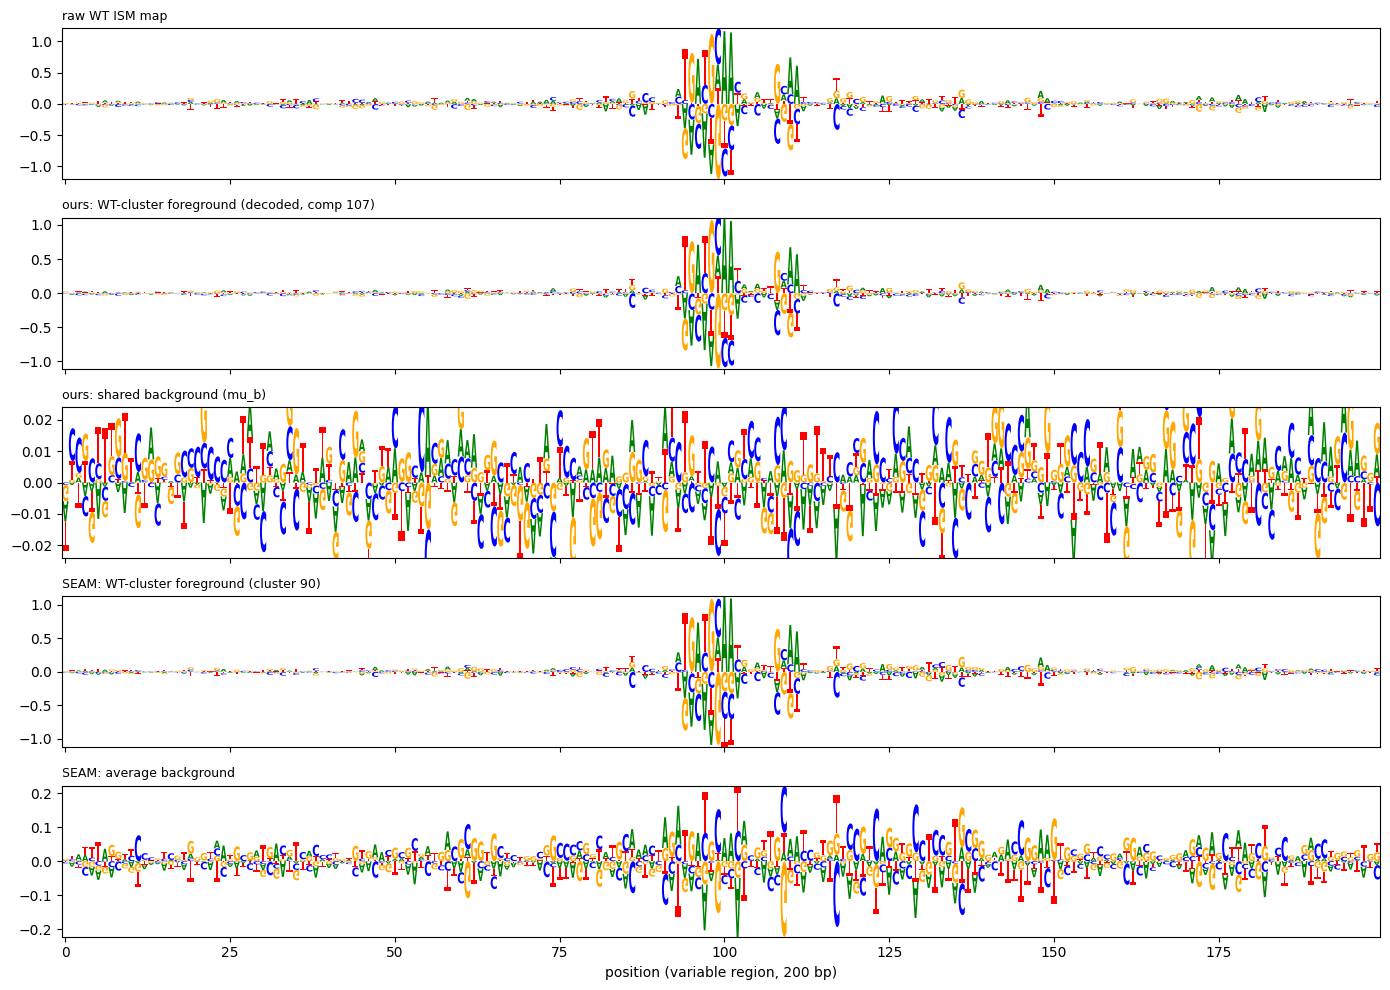

In [137]:
# ----- WT decomposition as sequence logos: our VAE-GMM vs SEAM -----
# WT is row 0 of the ISM library. Assign it to its VB cluster, decode that component's mean -> foreground;
# our background is the shared mu_b. SEAM counterpart: its WT cluster (ref_cluster_idx) foreground/background.
seam_k    = 100
seam_kdir = f"{seam_dir}/foregrounds{suffix}_kmeans{seam_k}/{peak}"
ref = int(np.load(f"{seam_kdir}/ref_cluster_idx.npy"))              # SEAM cluster containing the WT

model.eval()
with torch.no_grad():
    mu_z0, lv0 = model.encode(X_t[0:1])
    ElogN   = model.elogN(mu_z0, torch.exp(lv0))                     # (1,K)
    Elog_pi = torch.digamma(model.alpha) - torch.digamma(model.alpha.sum())
    c = int((Elog_pi[None] + ElogN).argmax(1))                      # our cluster containing the WT
    our_fg = model.decode(model.m_[c:c+1]).cpu().numpy().reshape(L, 4) # decoded cluster-mean foreground
    our_bg = model.mu_b.cpu().numpy().reshape(L, 4)                 # shared background

seam_fg = np.load(f"{seam_kdir}/cluster_maps.npy")[ref]            # (L,4) SEAM WT-cluster foreground
seam_bg = np.load(f"{seam_kdir}/average_background.npy")           # (L,4) SEAM global average background
raw_wt  = attributions[0]                                          # (L,4) raw WT ISM map

panels = [("raw WT ISM map",                                   raw_wt),
          (f"ours: WT-cluster foreground (decoded, comp {c})", our_fg),
          ("ours: shared background (mu_b)",                    our_bg),
          (f"SEAM: WT-cluster foreground (cluster {ref})",      seam_fg),
          ("SEAM: average background",                          seam_bg)]

fig, axes = plt.subplots(len(panels), 1, figsize=(14, 2.0 * len(panels)), sharex=True)
for ax, (title, arr) in zip(axes, panels):
    arr = np.asarray(arr, dtype=float)
    m = float(np.abs(arr).max()) or 1.0
    fast_logo(arr, ax, ylim=(-m, m))
    ax.set_title(title, fontsize=9, loc="left")
axes[-1].set_xlabel("position (variable region, 200 bp)")
plt.tight_layout(); plt.show()

loaded seqlet occupancy cache: /grid/koo/home/pmantill/projects/VBI/VAE_gmm/seperate_benchmark/results/peak84030.100k.seqlet_occupancy.npz  (52,767 maps with >=1 seqlet)
SEAM.kmeans100.100k  seqlet-overlap=0.845  (over 52,767 seqs)
RANDOM.k100  seqlet-overlap=0.395  (over 52,767 seqs)
peak84030.100k.J16.K200.h256.a0.001.warm50.mstep.ng.skip.rfdmu.seed13  seqlet-overlap=0.786  (over 52,767 seqs)
peak84030.100k.J16.K200.h256.a0.001.warm50.mstep.ng.skip.rfdmu.seed13.warmup_only  seqlet-overlap=0.797  (over 52,767 seqs)
peak84030.100k.J16.K200.h256.a0.1.warm50.mstep.ng.skip.rfdmu.seed13  seqlet-overlap=0.786  (over 52,767 seqs)
peak84030.100k.J16.K200.h256.a0.1.warm50.mstep.ng.skip.rfdmu.seed13.warmup_only  seqlet-overlap=0.797  (over 52,767 seqs)
peak84030.100k.J16.K200.h256.a1.warm30.mstep.ng.skip.rfdmu.seed13  seqlet-overlap=0.828  (over 52,767 seqs)
peak84030.100k.J16.K200.h256.a1.warm30.mstep.ng.skip.rfdmu.seed13.warmup_only  seqlet-overlap=0.822  (over 52,767 seqs)
peak84030.100k.J16

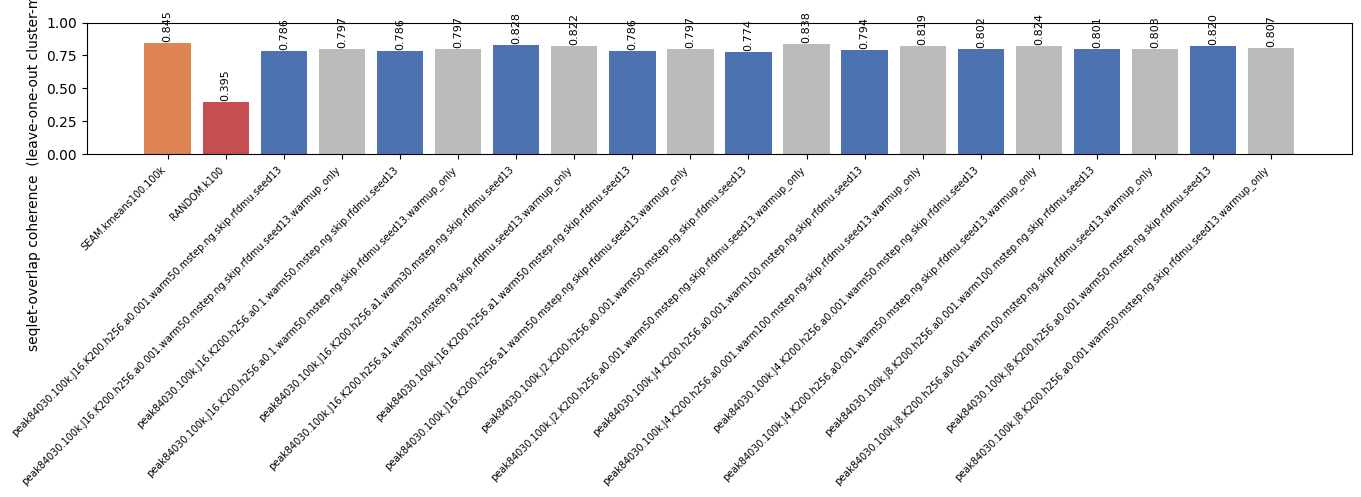

In [138]:
# ----- benchmark 2: seqlet-overlap coherence -----
# Recursive-seqlet-call every attribution map (tangermeme), then score each clustering by how much the
# seqlets of same-cluster sequences occupy the SAME positions. Per sequence: leave-one-out fraction of
# its seqlet positions that its cluster-mates also cover; the benchmark is the mean over all sequences.
# 1 = every cluster-mate's seqlets align perfectly; low = seqlets scattered within clusters.
from tangermeme.seqlet import recursive_seqlets

occ_cache = f"{out_dir}/{peak}.{lib}.seqlet_occupancy.npz"
if os.path.exists(occ_cache):
    occ = np.unpackbits(np.load(occ_cache)["occ"], axis=1)[:, :L].astype(bool)
    print(f"loaded seqlet occupancy cache: {occ_cache}  ({occ.any(1).sum():,} maps with >=1 seqlet)")
else:
    # projected attribution = attribution of the OBSERVED base at each position (variable region)
    with h5py.File(f"{seam_dir}/mutagenesis_lib{suffix}/{peak}.h5") as f:
        seqs = f["sequences"][:, 15:215, :]                    # (N,L,4) aligned to attributions
    proj = (attributions * seqs).sum(-1)                       # (N,L) per-position projected attribution
    df = recursive_seqlets(proj)                               # positive seqlets: example_idx,start,end,...
    occ = np.zeros((N, L), dtype=bool)
    for e, a, b in zip(df["example_idx"].to_numpy(), df["start"].to_numpy(), df["end"].to_numpy()):
        occ[e, a:b] = True
    np.savez_compressed(occ_cache, occ=np.packbits(occ, axis=1))
    print(f"called {len(df):,} seqlets over {N:,} maps; {occ.any(1).sum():,} have >=1 seqlet -> {occ_cache}")

def seqlet_overlap(labels):
    """mean leave-one-out fraction of each seq's seqlet positions shared by its cluster-mates."""
    labels = np.asarray(labels); Kc = int(labels.max()) + 1
    C = np.zeros((Kc, L), dtype=np.float64); np.add.at(C, labels, occ)   # (Kc,L) per-cluster coverage
    d  = occ.sum(1)                                            # (N,) |seqlet positions| per seq
    oc = (occ * C[labels]).sum(1)                              # (N,) sum of cluster counts over its positions
    sizes = np.bincount(labels, minlength=Kc); nk = sizes[labels]   # (N,) cluster size of each seq
    n_single = int((sizes == 1).sum())                        # singleton clusters (nk==1); returned per model
    valid = (d > 0) & (nk > 1)                                 # need a seqlet AND >=1 cluster-mate
    score = (oc[valid] - d[valid]) / ((nk[valid] - 1) * d[valid])   # leave-one-out fraction shared
    return float(score.mean()), int(valid.sum()), n_single

seam_labels = np.load(f"{seam_dir}/foregrounds{suffix}_kmeans{seam_k}/{peak}/cluster_labels.npy")
names2, overlaps, ncov = [], [], []
names2.append(f"SEAM.kmeans{seam_k}.{lib}")
s, v, ns = seqlet_overlap(seam_labels); overlaps.append(s); ncov.append(v)
print(f"{names2[-1]}  seqlet-overlap={s:.3f}  (over {v:,} seqs)" + (f"   [WARN {ns} singleton cluster(s)]" if ns else ""))

rand_labels = np.random.default_rng(0).integers(0, 100, N)   # random baseline: 100 uniform-random clusters
names2.append("RANDOM.k100")
s, v, ns = seqlet_overlap(rand_labels); overlaps.append(s); ncov.append(v)
print(f"{names2[-1]}  seqlet-overlap={s:.3f}  (over {v:,} seqs)" + (f"   [WARN {ns} singleton cluster(s)]" if ns else ""))
for cp in sorted(glob.glob(f"{out_dir}/{peak}.{lib}.*skip*.pt")):
    m, hp = load_model(cp)
    labels = responsibilities(m).argmax(1)
    s, v, ns = seqlet_overlap(labels)
    names2.append(os.path.basename(cp)[:-3]); overlaps.append(s); ncov.append(v)
    print(f"{names2[-1]}  seqlet-overlap={s:.3f}  (over {v:,} seqs)" + (f"   [WARN {ns} singleton cluster(s)]" if ns else ""))

colors2 = [bar_color(n) for n in names2]
fig, ax = plt.subplots(figsize=(0.6 * len(names2) + 2, 5))
ax.bar(range(len(names2)), overlaps, color=colors2)
for i, s in enumerate(overlaps):
    ax.text(i, s + 0.01, f"{s:.3f}", ha="center", va="bottom", fontsize=8, rotation=90)
ax.set_xticks(range(len(names2))); ax.set_xticklabels(names2, rotation=45, ha="right", fontsize=7)
ax.set_ylim(0, 1); ax.set_ylabel("seqlet-overlap coherence  (leave-one-out cluster-mate position agreement)")
plt.tight_layout(); plt.show()

SEAM.kmeans100.100k  within/across overlap ratio=2.27  (over 52,767 seqs)
RANDOM.k100  within/across overlap ratio=0.97  (over 52,767 seqs)
peak84030.100k.J16.K200.h256.a0.001.warm50.mstep.ng.skip.rfdmu.seed13  within/across overlap ratio=2.32  (over 52,767 seqs)
peak84030.100k.J16.K200.h256.a0.001.warm50.mstep.ng.skip.rfdmu.seed13.warmup_only  within/across overlap ratio=2.05  (over 52,767 seqs)
peak84030.100k.J16.K200.h256.a0.1.warm50.mstep.ng.skip.rfdmu.seed13  within/across overlap ratio=2.32  (over 52,767 seqs)
peak84030.100k.J16.K200.h256.a0.1.warm50.mstep.ng.skip.rfdmu.seed13.warmup_only  within/across overlap ratio=2.05  (over 52,767 seqs)
peak84030.100k.J16.K200.h256.a1.warm30.mstep.ng.skip.rfdmu.seed13  within/across overlap ratio=2.15  (over 52,767 seqs)
peak84030.100k.J16.K200.h256.a1.warm30.mstep.ng.skip.rfdmu.seed13.warmup_only  within/across overlap ratio=2.09  (over 52,767 seqs)
peak84030.100k.J16.K200.h256.a1.warm50.mstep.ng.skip.rfdmu.seed13  within/across overlap rat

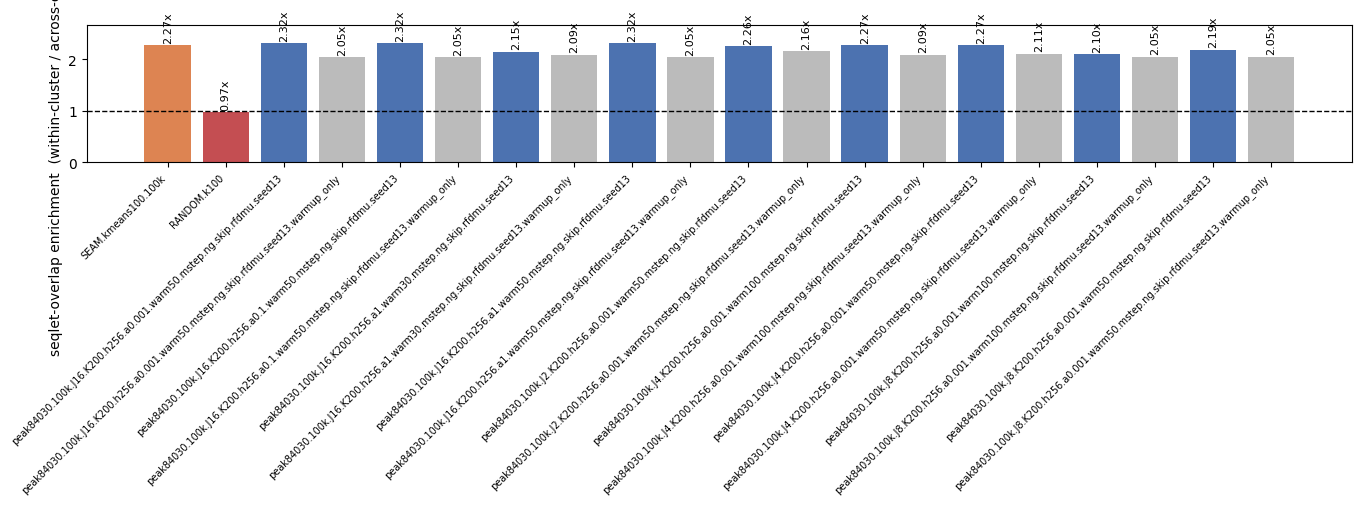

In [139]:
# ----- benchmark 3: seqlet-overlap coherence NORMALIZED by across-cluster overlap -----
# Benchmark 2 measures raw within-cluster seqlet-position overlap, which is inflated by globally popular
# positions (the WT motif) -- even random clusters score high. Here we divide each sequence's WITHIN-
# cluster overlap by its ACROSS-cluster (out-of-cluster) overlap: an enrichment ratio.
#   within_i  = LOO fraction of seq i's seqlet positions covered by its cluster-mates
#   across_i  = fraction of seq i's seqlet positions covered by sequences in OTHER clusters
#   ratio_i   = within_i / max(across_i, p0)   ->  1 = chance,  >1 = concentration  (p0 = global chance rate)
# Sequences whose seqlets are CLUSTER-EXCLUSIVE (across_i = 0) are KEPT, not dropped: across is floored at
# the global chance coverage rate p0, so an exclusive motif scores high (within/p0) instead of being omitted.
def seqlet_overlap_norm(labels):
    labels = np.asarray(labels); Kc = int(labels.max()) + 1
    C = np.zeros((Kc, L), dtype=np.float64); np.add.at(C, labels, occ)   # (Kc,L) per-cluster coverage
    Ctot = occ.sum(0)                                          # (L,) global coverage counts
    d  = occ.sum(1)                                            # (N,) |seqlet positions| per seq
    Ck = C[labels]                                             # (N,L) own-cluster counts
    oc_in  = (occ * Ck).sum(1)                                 # (N,) own-cluster count over its positions
    oc_tot = (occ * Ctot).sum(1)                               # (N,) global count over its positions
    sizes = np.bincount(labels, minlength=Kc); nk = sizes[labels]   # (N,) own-cluster size
    n_single = int((sizes == 1).sum())                        # singleton clusters (nk==1); returned per model
    within = (oc_in  - d) / np.maximum(nk - 1, 1) / np.maximum(d, 1)     # LOO within-cluster fraction
    across = (oc_tot - oc_in) / np.maximum(N - nk, 1) / np.maximum(d, 1) # out-of-cluster fraction
    p0 = float(occ.mean())                                    # chance coverage rate (random seq x position)
    valid  = (d > 0) & (nk > 1) & (nk < N)                    # KEEP cluster-exclusive seqlets (across may be 0)
    ratio  = within[valid] / np.maximum(across[valid], p0)    # floor across at chance so exclusives count, not dropped
    return float(ratio.mean()), int(valid.sum()), n_single

seam_labels = np.load(f"{seam_dir}/foregrounds{suffix}_kmeans{seam_k}/{peak}/cluster_labels.npy")
names3, ratios, ncov3 = [], [], []
names3.append(f"SEAM.kmeans{seam_k}.{lib}")
r, v, ns = seqlet_overlap_norm(seam_labels); ratios.append(r); ncov3.append(v)
print(f"{names3[-1]}  within/across overlap ratio={r:.2f}  (over {v:,} seqs)" + (f"   [WARN {ns} singleton cluster(s)]" if ns else ""))

rand_labels = np.random.default_rng(0).integers(0, 100, N)   # random baseline: 100 uniform-random clusters
names3.append("RANDOM.k100")
r, v, ns = seqlet_overlap_norm(rand_labels); ratios.append(r); ncov3.append(v)
print(f"{names3[-1]}  within/across overlap ratio={r:.2f}  (over {v:,} seqs)" + (f"   [WARN {ns} singleton cluster(s)]" if ns else ""))
for cp in sorted(glob.glob(f"{out_dir}/{peak}.{lib}.*skip*.pt")):
    m, hp = load_model(cp)
    labels = responsibilities(m).argmax(1)
    r, v, ns = seqlet_overlap_norm(labels)
    names3.append(os.path.basename(cp)[:-3]); ratios.append(r); ncov3.append(v)
    print(f"{names3[-1]}  within/across overlap ratio={r:.2f}  (over {v:,} seqs)" + (f"   [WARN {ns} singleton cluster(s)]" if ns else ""))

colors3 = [bar_color(n) for n in names3]
fig, ax = plt.subplots(figsize=(0.6 * len(names3) + 2, 5))
ax.bar(range(len(names3)), ratios, color=colors3)
ax.axhline(1.0, color="k", lw=1, ls="--")                    # 1 = no better than chance
for i, r in enumerate(ratios):
    ax.text(i, r + 0.02 * max(ratios), f"{r:.2f}x", ha="center", va="bottom", fontsize=8, rotation=90)
ax.set_xticks(range(len(names3))); ax.set_xticklabels(names3, rotation=45, ha="right", fontsize=7)
ax.set_ylim(0, max(ratios) * 1.15)
ax.set_ylabel("seqlet-overlap enrichment  (within-cluster / across-cluster position overlap)")
plt.tight_layout(); plt.show()